## Feature Importance Analysis for the Li-Air Overpotential Model

This notebook evaluates feature importance using permutation importance and SHAP analysis for the NGBoost Li-air overpotential model.

Workflow:
1. Load and prepare the dataset.
2. Split the data by compound.
3. Train and evaluate the NGBoost model.
4. Calculate permutation importance and SHAP importance.
5. Save importance data and figures.

In [1]:
# ============================================================
# 1. Import libraries
# ============================================================

from pathlib import Path

import joblib
import numpy as np
import pandas as pd

from ngboost import NGBRegressor
from ngboost.distns import Normal
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.model_selection import (
    GroupKFold,
    GroupShuffleSplit,
    cross_validate
)


In [2]:
# ============================================================
# 2. Configuration
# ============================================================

DATA_PATH = Path("data/6_air.xlsx")
SHEET_NAME = "Sheet1"

GROUP_COL = "compounds"

FEATURE_COLS = [
    "CurrentDensity",
    "O2",
    "CO2"
]

TARGET_COL = "overpotential"

RANDOM_STATE = 42
TEST_SIZE = 0.25
N_SPLITS = 5

MODEL_PATH = Path(
    "model/ngboost_air_6.pkl"
)

SCATTER_PATH = Path(
    "results/ngboost_air_scatter_data_6.xlsx"
)

CV_PATH = Path(
    "results/ngboost_air_cv_results_6.xlsx"
)

MODEL_PATH.parent.mkdir(
    parents=True,
    exist_ok=True
)

SCATTER_PATH.parent.mkdir(
    parents=True,
    exist_ok=True
)

In [3]:
# ============================================================
# 3. Load data
# ============================================================

data = pd.read_excel(
    DATA_PATH,
    sheet_name=SHEET_NAME
)

model_data = data[
    [
        GROUP_COL,
        *FEATURE_COLS,
        TARGET_COL
    ]
].dropna().copy()

X = model_data[
    FEATURE_COLS
].copy()

y = model_data[
    TARGET_COL
].copy()

groups = model_data[
    GROUP_COL
].astype(str).copy()

print(
    f"Samples: {len(model_data)}"
)

print(
    f"Compounds: {groups.nunique()}"
)

Samples: 499
Compounds: 85


In [4]:
# ============================================================
# 4. Train-test split
# ============================================================

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

train_idx, test_idx = next(
    splitter.split(
        X,
        y,
        groups=groups
    )
)

X_train = X.iloc[
    train_idx
].reset_index(drop=True)

X_test = X.iloc[
    test_idx
].reset_index(drop=True)

y_train = y.iloc[
    train_idx
].reset_index(drop=True)

y_test = y.iloc[
    test_idx
].reset_index(drop=True)

groups_train = groups.iloc[
    train_idx
].reset_index(drop=True)

groups_test = groups.iloc[
    test_idx
].reset_index(drop=True)

overlap = (
    set(groups_train)
    & set(groups_test)
)

assert len(overlap) == 0

print(
    f"Training samples: {len(X_train)}"
)

print(
    f"Test samples: {len(X_test)}"
)

print(
    f"Training compounds: {groups_train.nunique()}"
)

print(
    f"Test compounds: {groups_test.nunique()}"
)

Training samples: 377
Test samples: 122
Training compounds: 63
Test compounds: 22


In [5]:
# ============================================================
# 5. Define model
# ============================================================

model = NGBRegressor(
    Dist=Normal,
    n_estimators=300,
    learning_rate=0.003,
    minibatch_frac=0.8,
    col_sample=1.0,
    random_state=RANDOM_STATE,
    verbose=False
)


# ============================================================
# 6. Cross-validation, model training, and evaluation
# ============================================================

group_cv = GroupKFold(
    n_splits=N_SPLITS
)

scoring = {
    "R2": "r2",
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error"
}

cv_scores = cross_validate(
    model,
    X_train,
    y_train,
    groups=groups_train,
    cv=group_cv,
    scoring=scoring
)

cv_results = pd.DataFrame({
    "Fold": np.arange(
        1,
        N_SPLITS + 1
    ),
    "R2": cv_scores["test_R2"],
    "MAE": -cv_scores["test_MAE"],
    "RMSE": -cv_scores["test_RMSE"]
})

print("\nCross-validation results")
print(cv_results.to_string(index=False))

print("\nCross-validation summary")

for metric in [
    "R2",
    "MAE",
    "RMSE"
]:
    mean_value = cv_results[
        metric
    ].mean()

    std_value = cv_results[
        metric
    ].std(ddof=1)

    print(
        f"CV {metric}: "
        f"{mean_value:.6f} +/- "
        f"{std_value:.6f}"
    )


model.fit(
    X_train,
    y_train
)

train_prediction = model.predict(
    X_train
)

test_prediction = model.predict(
    X_test
)


def calculate_metrics(
    y_true,
    y_pred
):

    return {
        "R2": r2_score(
            y_true,
            y_pred
        ),
        "MAE": mean_absolute_error(
            y_true,
            y_pred
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_true,
                y_pred
            )
        )
    }


train_metrics = calculate_metrics(
    y_train,
    train_prediction
)

test_metrics = calculate_metrics(
    y_test,
    test_prediction
)

print("\nTraining results")

print(
    f"R2:   {train_metrics['R2']:.6f}"
)

print(
    f"MAE:  {train_metrics['MAE']:.6f}"
)

print(
    f"RMSE: {train_metrics['RMSE']:.6f}"
)

print("\nTest results")

print(
    f"R2:   {test_metrics['R2']:.6f}"
)

print(
    f"MAE:  {test_metrics['MAE']:.6f}"
)

print(
    f"RMSE: {test_metrics['RMSE']:.6f}"
)



Cross-validation results
 Fold       R2      MAE     RMSE
    1 0.746084 0.144569 0.179950
    2 0.817505 0.104625 0.179318
    3 0.750017 0.175509 0.249323
    4 0.864805 0.122629 0.155973
    5 0.851484 0.102573 0.142864

Cross-validation summary
CV R2: 0.805979 +/- 0.055640
CV MAE: 0.129981 +/- 0.030552
CV RMSE: 0.181486 +/- 0.041084

Training results
R2:   0.872230
MAE:  0.111023
RMSE: 0.150904

Test results
R2:   0.849777
MAE:  0.120649
RMSE: 0.166375



Permutation importance
CO2             0.822366 +/- 0.092451
O2              0.543809 +/- 0.049627
CurrentDensity  0.005724 +/- 0.002676


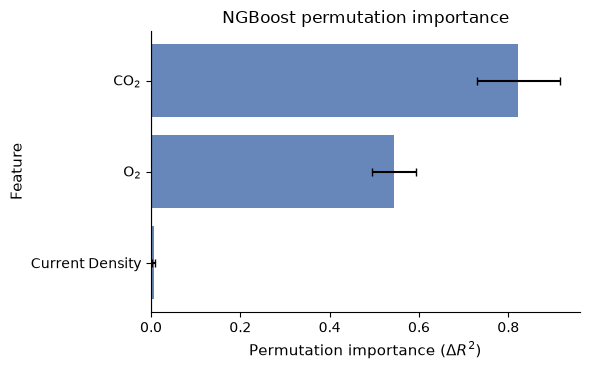


Permutation importance data saved to: results\ngboost_air_permutation_importance.xlsx


In [6]:
# ============================================================
# 9. Permutation importance
# ============================================================

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.inspection import permutation_importance


IMPORTANCE_DIR = Path("results")
IMPORTANCE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

DISPLAY_NAMES = np.array([
    "Current Density",
    r"O$_2$",
    r"CO$_2$"
])

permutation_result = permutation_importance(
    estimator=model,
    X=X_test,
    y=y_test.to_numpy().reshape(-1),
    scoring="r2",
    n_repeats=30,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

importance_mean = (
    permutation_result.importances_mean
)

importance_std = (
    permutation_result.importances_std
)

permutation_data = pd.DataFrame({
    "Feature": FEATURE_COLS,
    "Display_Name": DISPLAY_NAMES,
    "Importance_Mean": importance_mean,
    "Importance_Std": importance_std
}).sort_values(
    "Importance_Mean",
    ascending=False
).reset_index(drop=True)

print("\nPermutation importance")

for _, row in permutation_data.iterrows():

    print(
        f"{row['Feature']:<15} "
        f"{row['Importance_Mean']:.6f} +/- "
        f"{row['Importance_Std']:.6f}"
    )

plot_data = permutation_data.sort_values(
    "Importance_Mean",
    ascending=True
)

fig, ax = plt.subplots(
    figsize=(6.0, 3.8)
)

ax.barh(
    plot_data["Display_Name"],
    plot_data["Importance_Mean"],
    xerr=plot_data["Importance_Std"],
    color="#4C72B0",
    alpha=0.85,
    capsize=3
)

ax.axvline(
    x=0,
    color="black",
    linewidth=0.8
)

ax.set_xlabel(
    r"Permutation importance ($\Delta R^2$)",
    fontsize=11
)

ax.set_ylabel(
    "Feature",
    fontsize=11
)

ax.set_title(
    "NGBoost permutation importance",
    fontsize=12
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()

plt.show()

permutation_path = (
    IMPORTANCE_DIR
    / "ngboost_air_permutation_importance.xlsx"
)

permutation_data.to_excel(
    permutation_path,
    index=False
)

print(
    f"\nPermutation importance data saved to: "
    f"{permutation_path}"
)

D:\app\miniconda\envs\mp311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
100%|██████████| 122/122 [00:51<00:00,  2.36it/s]



SHAP importance
CO2                  0.181937 +/- 0.108605 (62.15%)
O2                   0.093376 +/- 0.101522 (31.90%)
CurrentDensity       0.017443 +/- 0.011058 (5.96%)


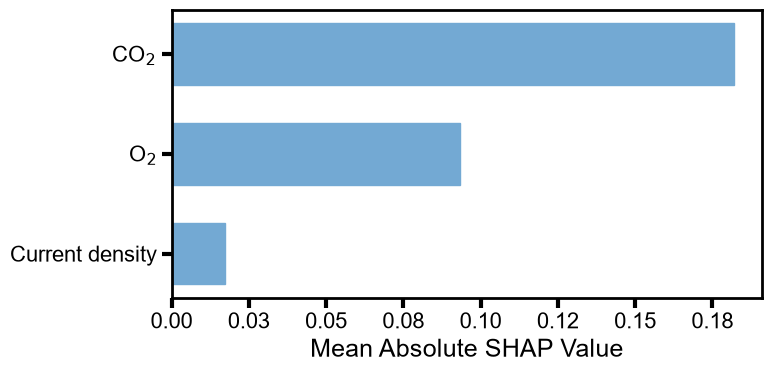

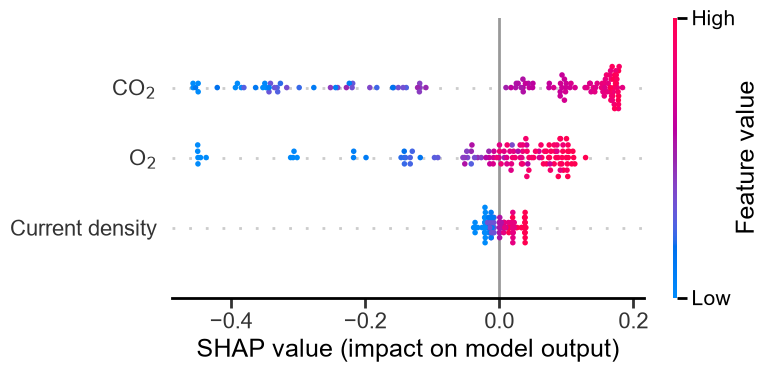


SHAP results saved to:
figure\importance\ngboost_air_shap_bar.png
figure\importance\ngboost_air_shap_beeswarm.png
figure\importance\ngboost_air_shap_results.xlsx


In [7]:
# ============================================================
# 10. SHAP analysis
# ============================================================

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

from matplotlib.ticker import FormatStrFormatter
from sklearn.utils import check_random_state


warnings.filterwarnings("ignore")


# ============================================================
# 10.1 Configuration
# ============================================================

IMPORTANCE_DIR = Path(
    "figure/importance"
)

IMPORTANCE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

DISPLAY_NAMES = [
    "Current density",
    r"O$_2$",
    r"CO$_2$"
]

if len(FEATURE_COLS) != len(DISPLAY_NAMES):
    raise ValueError(
        "The number of display names does not match "
        "the number of model features."
    )


# Use Arial font
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 16,
    "axes.linewidth": 3,
    "xtick.major.width": 3,
    "ytick.major.width": 3,
    "xtick.major.size": 7,
    "ytick.major.size": 7,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})


# ============================================================
# 10.2 Prepare the SHAP datasets
# ============================================================

X_train_df = X_train[
    FEATURE_COLS
].copy()

X_test_df = X_test[
    FEATURE_COLS
].copy()

rng = check_random_state(
    RANDOM_STATE
)

background_size = min(
    200,
    len(X_train_df)
)

explanation_size = min(
    200,
    len(X_test_df)
)

background_idx = rng.choice(
    len(X_train_df),
    size=background_size,
    replace=False
)

explanation_idx = rng.choice(
    len(X_test_df),
    size=explanation_size,
    replace=False
)

X_background = X_train_df.iloc[
    background_idx
].copy()

X_explain = X_test_df.iloc[
    explanation_idx
].copy()


# ============================================================
# 10.3 Define the prediction function
# ============================================================

def predict_function(values):

    if isinstance(values, pd.DataFrame):

        input_data = values[
            FEATURE_COLS
        ].copy()

    else:

        input_data = pd.DataFrame(
            values,
            columns=FEATURE_COLS
        )

    prediction = model.predict(
        input_data
    )

    return np.asarray(
        prediction
    ).reshape(-1)


# ============================================================
# 10.4 Calculate SHAP values
# ============================================================

explainer = shap.KernelExplainer(
    predict_function,
    X_background
)

shap_values = explainer.shap_values(
    X_explain,
    nsamples=300
)

if isinstance(shap_values, list):
    shap_values = shap_values[0]

shap_values = np.asarray(
    shap_values
)

if shap_values.ndim == 3:
    shap_values = shap_values[:, :, 0]

if shap_values.shape[1] != len(FEATURE_COLS):
    raise ValueError(
        "The number of SHAP columns does not match "
        "the number of model features."
    )


# ============================================================
# 10.5 Calculate SHAP importance
# ============================================================

absolute_shap = np.abs(
    shap_values
)

mean_abs_shap = absolute_shap.mean(
    axis=0
)

if len(X_explain) > 1:

    std_abs_shap = absolute_shap.std(
        axis=0,
        ddof=1
    )

else:

    std_abs_shap = np.zeros(
        len(FEATURE_COLS)
    )

total_importance = mean_abs_shap.sum()

if total_importance == 0:

    contribution_percent = np.zeros(
        len(FEATURE_COLS)
    )

else:

    contribution_percent = (
        100
        * mean_abs_shap
        / total_importance
    )

shap_importance = pd.DataFrame({
    "Feature": FEATURE_COLS,
    "Display_Name": DISPLAY_NAMES,
    "Mean_Absolute_SHAP": mean_abs_shap,
    "Std_Absolute_SHAP": std_abs_shap,
    "Contribution_Percent": contribution_percent
})

shap_importance = (
    shap_importance
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\nSHAP importance")

for _, row in shap_importance.iterrows():

    print(
        f"{row['Feature']:<20} "
        f"{row['Mean_Absolute_SHAP']:.6f} +/- "
        f"{row['Std_Absolute_SHAP']:.6f} "
        f"({row['Contribution_Percent']:.2f}%)"
    )


# ============================================================
# 10.6 Plot and save the SHAP bar figure
# ============================================================

plot_order = np.argsort(
    mean_abs_shap
)

sorted_importance = mean_abs_shap[
    plot_order
]

sorted_names = np.asarray(
    DISPLAY_NAMES
)[plot_order]

fig_bar, ax_bar = plt.subplots(
    figsize=(8, 4)
)

ax_bar.barh(
    np.arange(len(sorted_names)),
    sorted_importance,
    height=0.62,
    color="#73A9D3",
    edgecolor="#73A9D3"
)

ax_bar.set_yticks(
    np.arange(len(sorted_names))
)

ax_bar.set_yticklabels(
    sorted_names,
    fontsize=17
)

ax_bar.set_xlabel(
    "Mean Absolute SHAP Value",
    fontsize=18
)

# Keep two decimal places on the x-axis
ax_bar.xaxis.set_major_formatter(
    FormatStrFormatter("%.2f")
)

ax_bar.tick_params(
    axis="both",
    direction="out",
    width=3,
    length=7,
    labelsize=16
)

for spine in ax_bar.spines.values():
    spine.set_linewidth(2)

fig_bar.tight_layout()

bar_png_path = (
    IMPORTANCE_DIR
    / "ngboost_air_shap_bar.png"
)

fig_bar.savefig(
    bar_png_path,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close(fig_bar)


# ============================================================
# 10.7 Plot and save the SHAP beeswarm figure
# ============================================================

fig_beeswarm = plt.figure(
    figsize=(8, 4)
)

shap.summary_plot(
    shap_values,
    X_explain.to_numpy(),
    feature_names=DISPLAY_NAMES,
    show=False,
    plot_size=None,
    color_bar=True
)

ax_beeswarm = plt.gca()

ax_beeswarm.set_xlabel(
    "SHAP value (impact on model output)",
    fontsize=18
)

ax_beeswarm.set_ylabel("")

ax_beeswarm.tick_params(
    axis="both",
    direction="out",
    width=2,
    length=7,
    labelsize=16
)

# Format the reference lines
for line in ax_beeswarm.lines:
    line.set_linewidth(2)

# Format the axes
ax_beeswarm.spines["bottom"].set_linewidth(2)
ax_beeswarm.spines["left"].set_linewidth(2)
ax_beeswarm.spines["top"].set_visible(False)
ax_beeswarm.spines["right"].set_visible(False)


# Format the color bar
for axis in fig_beeswarm.axes:

    if axis is not ax_beeswarm:

        axis.set_ylabel(
            "Feature value",
            fontsize=18
        )

        axis.tick_params(
            width=2,
            length=7,
            labelsize=15
        )

fig_beeswarm.tight_layout()

beeswarm_png_path = (
    IMPORTANCE_DIR
    / "ngboost_air_shap_beeswarm.png"
)

fig_beeswarm.savefig(
    beeswarm_png_path,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close(fig_beeswarm)


# ============================================================
# 10.8 Save the SHAP data
# ============================================================

shap_detail = X_explain.copy()

shap_detail.insert(
    0,
    "Sample_Index",
    X_explain.index.to_numpy()
)

for feature_index, feature in enumerate(
    FEATURE_COLS
):

    shap_detail[
        f"{feature}_SHAP"
    ] = shap_values[:, feature_index]

shap_path = (
    IMPORTANCE_DIR
    / "ngboost_air_shap_results.xlsx"
)

with pd.ExcelWriter(
    shap_path
) as writer:

    shap_importance.to_excel(
        writer,
        sheet_name="SHAP_Importance",
        index=False
    )

    shap_detail.to_excel(
        writer,
        sheet_name="SHAP_Values",
        index=False
    )


# ============================================================
# 10.9 Print saved paths
# ============================================================

print(
    f"\nSHAP results saved to:\n"
    f"{bar_png_path}\n"
    f"{beeswarm_png_path}\n"
    f"{shap_path}"
)